# UAS NLP - Eksperimen ABSA & NER
Domain: Review aplikasi Grab di Google Play Store (bahasa Indonesia)


In [1]:
# !pip install google-play-scraper Sastrawi nltk scikit-learn pandas numpy matplotlib seaborn joblib python-Levenshtein


In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re
import joblib
import torch
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from google_play_scraper import reviews, Sort
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AutoModelForTokenClassification, Trainer, TrainingArguments
from torch.utils.data import Dataset
import Levenshtein

nltk.download('punkt')
nltk.download('punkt_tab')

# Membuat direktori data dan models jika belum ada
os.makedirs('../data', exist_ok=True)
os.makedirs('../models', exist_ok=True)

# Seed untuk reproducibility
RANDOM_STATE = 42
TEST_SIZE = 0.2
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ACER\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ACER\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


## Bagian 1: Scraping Data
Langkah ini melakukan scraping ulasan aplikasi Grab dari Google Play Store. Kami memfilter ulasan berbahasa Indonesia dan menyimpannya ke `data/raw_reviews.csv`.


In [3]:
# Scraping 500+ review dari Grab
result, continuation_token = reviews(
    'com.grabtaxi.passenger',
    lang='id', 
    country='id', 
    sort=Sort.NEWEST, 
    count=5000 
)

df_raw = pd.DataFrame(result)
df_raw = df_raw[['content', 'score']]
df_raw.rename(columns={'content': 'text'}, inplace=True)

# Menyimpan data mentah
df_raw.to_csv('../data/raw_reviews.csv', index=False)

# Menampilkan 5 sampel
display(df_raw.head())


,text,score
0,"bintang 3 dulu,yang jadi pertanyaan saya adala...",3
1,"grab knp jahat sm cewe aku, jangan lah kayak gitu",1
2,"babi, aplikasi grab merchant mu susah dipake",1
3,bagus aplikasi ini membantu semua orng,5
4,pengemudi di apk sering tidak bergerak dan tid...,3


EDA 1 - DATASET MENTAH (raw_reviews.csv)

1. Jumlah total review   : 5000
Jumlah kolom          : 2
Kolom                 : ['text', 'score']
Data duplikat         : 1397

Data kosong (null) per kolom:
text     0
score    0

2. Distribusi Rating (Score):
score
1    1445
2     170
3     175
4     218
5    2992

Rata-rata score : 3.63
Median score    : 5.0

3. Visualisasi Distribusi Rating:

3. Panjang Teks:


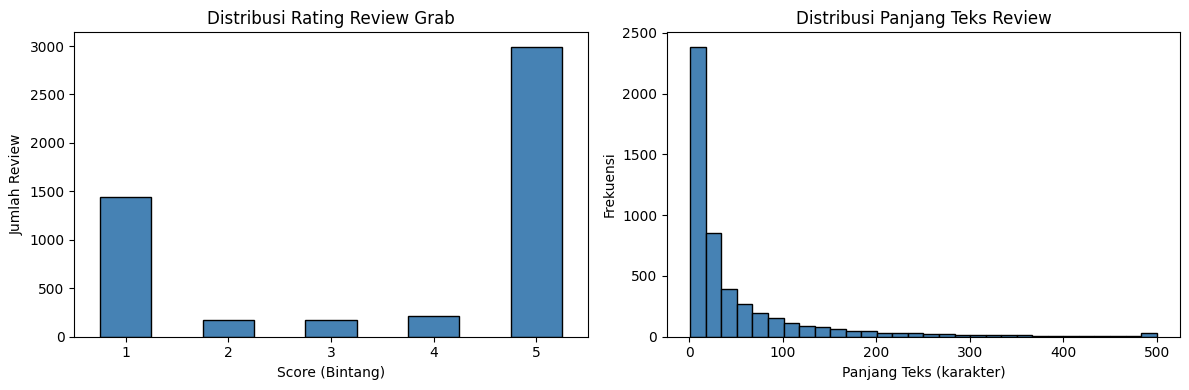


Panjang teks minimum  : 1 karakter
Panjang teks maksimum : 500 karakter
Rata-rata panjang     : 52.0 karakter

Contoh 5 Baris Data Mentah:


,text,score
0,"bintang 3 dulu,yang jadi pertanyaan saya adala...",3
1,"grab knp jahat sm cewe aku, jangan lah kayak gitu",1
2,"babi, aplikasi grab merchant mu susah dipake",1
3,bagus aplikasi ini membantu semua orng,5
4,pengemudi di apk sering tidak bergerak dan tid...,3


In [4]:
# ============================================================
# EDA 1 - Analisis Dataset Mentah (Setelah Scraping)
# ============================================================

print("=" * 55)
print("EDA 1 - DATASET MENTAH (raw_reviews.csv)")
print("=" * 55)

# Info dasar
print(f"\n1. Jumlah total review   : {len(df_raw)}")
print(f"Jumlah kolom          : {df_raw.shape[1]}")
print(f"Kolom                 : {list(df_raw.columns)}")
print(f"Data duplikat         : {df_raw.duplicated().sum()}")
print(f"\nData kosong (null) per kolom:")
print(df_raw.isnull().sum().to_string())

# Distribusi rating
print(f"\n2. Distribusi Rating (Score):")
print(df_raw['score'].value_counts().sort_index().to_string())
print(f"\nRata-rata score : {df_raw['score'].mean():.2f}")
print(f"Median score    : {df_raw['score'].median():.1f}")

# Visualisasi distribusi rating\
print(f"\n3. Visualisasi Distribusi Rating:")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_raw['score'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='black'
)
axes[0].set_title('Distribusi Rating Review Grab')
axes[0].set_xlabel('Score (Bintang)')
axes[0].set_ylabel('Jumlah Review')
axes[0].tick_params(axis='x', rotation=0)

# Panjang teks
print(f"\n3. Panjang Teks:")

df_raw['text_length'] = df_raw['text'].astype(str).apply(len)
axes[1].hist(df_raw['text_length'], bins=30, color='steelblue', edgecolor='black')
axes[1].set_title('Distribusi Panjang Teks Review')
axes[1].set_xlabel('Panjang Teks (karakter)')
axes[1].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

print(f"\nPanjang teks minimum  : {df_raw['text_length'].min()} karakter")
print(f"Panjang teks maksimum : {df_raw['text_length'].max()} karakter")
print(f"Rata-rata panjang     : {df_raw['text_length'].mean():.1f} karakter")

# Tampilkan 5 sampel
print("\nContoh 5 Baris Data Mentah:")
display(df_raw[['text', 'score']].head())


## Bagian 2: Preprocessing
Di bagian ini, kita membersihkan teks:
1. Case folding (huruf kecil)
2. Cleaning URL, mention, simbol, angka
3. Normalisasi slang/typo menggunakan kamus sederhana
4. Tokenisasi dengan NLTK
5. Stopword removal dan Stemming dengan Sastrawi


In [5]:
# Inisialisasi Sastrawi
factory_stemmer = StemmerFactory()
stemmer = factory_stemmer.create_stemmer()

factory_stopword = StopWordRemoverFactory()
default_stopwords = set(factory_stopword.get_stop_words())
# Kata negasi/penting yang dikecualikan agar tidak mengubah polaritas sentimen
ignored_stopwords = {'tidak', 'jangan', 'kurang', 'bukan', 'belum', 'tidaklah'}
custom_stopwords = default_stopwords - ignored_stopwords

# Kamus slang/typo (minimal 20 kata)
slang_dict = {
    'yg': 'yang', 'dgn': 'dengan', 'utk': 'untuk', 'bs': 'bisa', 'gk': 'tidak',
    'ga': 'tidak', 'gak': 'tidak', 'tdk': 'tidak', 'bgt': 'banget', 'bgs': 'bagus',
    'klo': 'kalau', 'kalo': 'kalau', 'sm': 'sama', 'dr': 'dari', 'jd': 'jadi',
    'jgn': 'jangan', 'nya': '', 'udh': 'sudah', 'sdh': 'sudah', 'tp': 'tapi',
    'drivernya': 'driver', 'aplikasinya': 'aplikasi', 'sy': 'saya', 'jg': 'juga',
    'kpd': 'kepada', 'krn': 'karena', 'bikin': 'buat'
}

def clean_text(text):
    # 1. Case folding
    text = text.lower()
    # 2. Cleaning URL, mention, simbol, angka
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def normalize_slang(text):
    words = text.split()
    normalized = [slang_dict.get(word, word) for word in words]
    return ' '.join(normalized)

def preprocess(text):
    text = clean_text(text)
    text = normalize_slang(text)
    # Stopword removal dengan custom stopword list
    words = text.split()
    filtered = [w for w in words if w not in custom_stopwords]
    text = ' '.join(filtered)
    # Stemming Sastrawi
    text = stemmer.stem(text)
    return text

# Mengaplikasikan preprocessing (menggunakan 500 sampel agar dataset lebih besar & representatif)
df_prep = df_raw.copy()
df_prep['clean_text'] = df_prep['text'].apply(preprocess)
# Tokenisasi menggunakan nltk
df_prep['tokens'] = df_prep['clean_text'].apply(nltk.word_tokenize)

# Tampilkan before-after (10 baris)
display(df_prep[['text', 'clean_text', 'tokens']].head(10))


,text,clean_text,tokens
0,"bintang 3 dulu,yang jadi pertanyaan saya adala...",bintang dulu jadi tanya aplikasi pas baru mau ...,"[bintang, dulu, jadi, tanya, aplikasi, pas, ba..."
1,"grab knp jahat sm cewe aku, jangan lah kayak gitu",grab knp jahat sama cewe aku jangan lah kayak ...,"[grab, knp, jahat, sama, cewe, aku, jangan, la..."
2,"babi, aplikasi grab merchant mu susah dipake",babi aplikasi grab merchant mu susah dipake,"[babi, aplikasi, grab, merchant, mu, susah, di..."
3,bagus aplikasi ini membantu semua orng,bagus aplikasi bantu semua orng,"[bagus, aplikasi, bantu, semua, orng]"
4,pengemudi di apk sering tidak bergerak dan tid...,kemudi apk sering tidak gerak tidak respon dichat,"[kemudi, apk, sering, tidak, gerak, tidak, res..."
5,nice,nice,[nice]
6,mantabbbb,mantabbbb,[mantabbbb]
7,bagus,bagus,[bagus]
8,overall bagus cuman kalau untuk daerah pinggir...,overall bagus cuman kalau daerah pinggir suka ...,"[overall, bagus, cuman, kalau, daerah, pinggir..."
9,sgt cepat pengantaran nya. sukses selalu grab,sgt cepat antar sukses selalu grab,"[sgt, cepat, antar, sukses, selalu, grab]"


## Bagian 3: Regex / FSA
Menggunakan Regex untuk:
1. Ekstraksi kandidat aspek (kata benda seperti driver, aplikasi, harga, layanan).
2. Deteksi ekspresi rating/bintang (contoh: "bintang 5", "1 bintang").


In [6]:
def extract_aspect_candidates(text):
    # Aspek yang umum di domain transportasi/ojol
    pattern = r'\b(driver|supir|aplikasi|app|harga|ongkir|tarif|layanan|pelayanan|aman|keamanan|promo|diskon|map|peta)\b'
    matches = re.findall(pattern, text, re.IGNORECASE)
    return list(set(matches))

def detect_rating_expression(text):
    # Mendeteksi ekspresi rating
    pattern = r'\b(?:bintang\s*\d|\d\s*bintang|rate\s*\d|rating\s*\d)\b'
    matches = re.findall(pattern, text, re.IGNORECASE)
    return matches

print("Contoh Ekstraksi Aspek & Rating:")
sample_texts = [
    "driver nya ramah banget, aplikasinya juga gampang dipake, bintang 5 deh!",
    "kecewa sama harga yang makin mahal, saya kasih 1 bintang untuk app ini.",
    "banyak promo dan diskon, driver cepat sampai"
]

for t in sample_texts:
    print(f"Teks: {t}")
    print(f"Aspek: {extract_aspect_candidates(t)}")
    print(f"Rating: {detect_rating_expression(t)}\n")


Contoh Ekstraksi Aspek & Rating:
Teks: driver nya ramah banget, aplikasinya juga gampang dipake, bintang 5 deh!
Aspek: ['driver']
Rating: ['bintang 5']

Teks: kecewa sama harga yang makin mahal, saya kasih 1 bintang untuk app ini.
Aspek: ['harga', 'app']
Rating: ['1 bintang']

Teks: banyak promo dan diskon, driver cepat sampai
Aspek: ['promo', 'driver', 'diskon']
Rating: []



## Bagian 4: Representasi Teks
Di bagian ini, kita akan mengubah teks yang sudah dibersihkan ke dalam bentuk vektor numerik. Metode yang digunakan adalah:
1. Bag of Words (BoW)
2. N-Gram (Bigram)
3. TF-IDF

**Penjelasan Sparse Representation:**
Sparse representation adalah representasi matriks di mana sebagian besar elemennya bernilai nol (0). Dalam pemrosesan teks, jumlah kosakata (vocabulary) unik dalam seluruh dokumen sangat besar, tetapi setiap kalimat (dokumen) hanya mengandung sedikit kosakata tersebut. Oleh karena itu, matriks vektor teks akan dipenuhi oleh angka nol, sehingga disebut *sparse matrix*. Format ini hemat memori karena algoritma hanya menyimpan nilai yang tidak nol.


In [7]:
corpus = df_prep['clean_text'].tolist()

# 1. Bag of Words (BoW)
bow_vectorizer = CountVectorizer()
X_bow = bow_vectorizer.fit_transform(corpus)

# 2. N-Gram (Bigram)
bigram_vectorizer = CountVectorizer(ngram_range=(2, 2))
X_bigram = bigram_vectorizer.fit_transform(corpus)

# 3. TF-IDF
tfidf_vectorizer = TfidfVectorizer()
X_tfidf = tfidf_vectorizer.fit_transform(corpus)

print("Bag of Words - Shape:", X_bow.shape)
print("BoW Top 20 terms:", list(bow_vectorizer.vocabulary_.keys())[:20])
print("\nBigram - Shape:", X_bigram.shape)
print("Bigram Top 20 terms:", list(bigram_vectorizer.vocabulary_.keys())[:20])
print("\nTF-IDF - Shape:", X_tfidf.shape)
print("TF-IDF Top 20 terms:", list(tfidf_vectorizer.vocabulary_.keys())[:20])


Bag of Words - Shape: (5000, 4187)
BoW Top 20 terms: ['bintang', 'dulu', 'jadi', 'tanya', 'aplikasi', 'pas', 'baru', 'mau', 'download', 'tulis', 'rupa', 'mungkin', 'tidak', 'fungsi', 'perangkat', 'mohon', 'cek', 'yah', 'grab', 'knp']

Bigram - Shape: (5000, 20523)
Bigram Top 20 terms: ['bintang dulu', 'dulu jadi', 'jadi tanya', 'tanya aplikasi', 'aplikasi pas', 'pas baru', 'baru mau', 'mau download', 'download tulis', 'tulis aplikasi', 'aplikasi rupa', 'rupa mungkin', 'mungkin tidak', 'tidak fungsi', 'fungsi perangkat', 'perangkat mohon', 'mohon cek', 'cek yah', 'grab knp', 'knp jahat']

TF-IDF - Shape: (5000, 4187)
TF-IDF Top 20 terms: ['bintang', 'dulu', 'jadi', 'tanya', 'aplikasi', 'pas', 'baru', 'mau', 'download', 'tulis', 'rupa', 'mungkin', 'tidak', 'fungsi', 'perangkat', 'mohon', 'cek', 'yah', 'grab', 'knp']


## Bagian 5: Similarity
Kita menggunakan Minimum Edit Distance (Levenshtein) untuk mendeteksi typo dan Cosine Similarity untuk mencari kemiripan antar dokumen/review.


In [8]:
from sklearn.metrics.pairwise import cosine_similarity

# 1. Minimum Edit Distance (Typo Correction)
typos = [("drver", "driver"), ("apikasi", "aplikasi"), ("harag", "harga"), ("laynan", "layanan"), ("pmro", "promo")]
typo_results = []
for wrong, right in typos:
    dist = Levenshtein.distance(wrong, right)
    typo_results.append({'Salah': wrong, 'Benar': right, 'Edit Distance': dist})

df_typo = pd.DataFrame(typo_results)
print("Tabel Minimum Edit Distance (Koreksi Typo):")
display(df_typo)

# 2. Cosine Similarity — gunakan kalimat representatif bukan 5 baris pertama corpus
sample_sentences = [
    "driver grab ramah cepat sampai tujuan",
    "driver ojek online ramah dan tepat waktu",
    "aplikasi grab sering error tidak bisa dibuka",
    "aplikasi crash terus susah digunakan",
    "harga grabcar mahal tidak sesuai jarak",
    "tarif grab terlalu mahal dibanding kompetitor",
    "layanan grab bagus pelanggan puas",
    "keamanan grabbike terjamin helm selalu ada"
]

tfidf_sim = TfidfVectorizer()
X_sim = tfidf_sim.fit_transform(sample_sentences)
sim_matrix = cosine_similarity(X_sim)

sim_results = []
for i in range(len(sample_sentences)):
    for j in range(i+1, len(sample_sentences)):
        sim_results.append({
            'Teks 1': sample_sentences[i],
            'Teks 2': sample_sentences[j],
            'Cosine Similarity': round(sim_matrix[i][j], 4)
        })

df_sim = pd.DataFrame(sim_results)
df_sim_top = df_sim.sort_values('Cosine Similarity', ascending=False).head(5).reset_index(drop=True)
print("\nTop 5 Pasang Kalimat Paling Mirip (Cosine Similarity):")
display(df_sim_top)

Tabel Minimum Edit Distance (Koreksi Typo):


,Salah,Benar,Edit Distance
0,drver,driver,1
1,apikasi,aplikasi,1
2,harag,harga,2
3,laynan,layanan,1
4,pmro,promo,3



Top 5 Pasang Kalimat Paling Mirip (Cosine Similarity):


,Teks 1,Teks 2,Cosine Similarity
0,driver grab ramah cepat sampai tujuan,driver ojek online ramah dan tepat waktu,0.2532
1,aplikasi grab sering error tidak bisa dibuka,aplikasi crash terus susah digunakan,0.1344
2,harga grabcar mahal tidak sesuai jarak,tarif grab terlalu mahal dibanding kompetitor,0.1337
3,aplikasi grab sering error tidak bisa dibuka,harga grabcar mahal tidak sesuai jarak,0.1254
4,driver grab ramah cepat sampai tujuan,layanan grab bagus pelanggan puas,0.0874


## Bagian 6: Labeling ABSA
- Aspek yang digunakan: [driver, aplikasi, harga, layanan, keamanan]
- Sentimen: [positif, negatif, netral]
Kami menggunakan rule-based mapping kata sifat untuk auto-labeling sentimen, dan pencarian kata kunci untuk deteksi aspek.


In [9]:
# Ubah kata kunci aspek agar sesuai dengan bentuk kata hasil stemming Sastrawi
aspect_keywords = {
    'driver': ['driver', 'supir', 'pengemudi'],
    'aplikasi': ['aplikasi', 'app', 'apk', 'sistem'],
    'harga': ['harga', 'ongkir', 'tarif', 'biaya'],
    'layanan': ['layan', 'pelayanan', 'respon', 'cs'], # 'layanan' di-stem menjadi 'layan'
    'keamanan': ['aman', 'keamanan', 'safety']         # 'keamanan' di-stem menjadi 'aman'
}
positive_words = ['bagus', 'cepat', 'ramah', 'murah', 'mantap', 'baik', 'keren', 'mudah', 'bantu', 'aman', 'top']
negative_words = ['jelek', 'lambat', 'mahal', 'buruk', 'kasar', 'susah', 'error', 'kecewa', 'tipu', 'lelet', 'kurang']
def auto_label_absa(text):
    text_lower = text.lower()
    
    # Deteksi aspek dengan keyword yang disesuaikan
    found_aspect = 'lainnya' # Default jika tidak ketemu
    for asp, keywords in aspect_keywords.items():
        for kw in keywords:
            if kw in text_lower:
                found_aspect = asp
                break
    
    if not found_aspect:
        found_aspect = 'layanan'
    
    # Deteksi sentimen
    pos_count = sum([1 for w in positive_words if w in text_lower])
    neg_count = sum([1 for w in negative_words if w in text_lower])
    
    if pos_count > neg_count:
        sentiment = 'positif'
    elif neg_count > pos_count:
        sentiment = 'negatif'
    else:
        sentiment = 'netral'
        
    return found_aspect, sentiment

# Apply ke seluruh dataset
df_prep['aspect'], df_prep['sentiment'] = zip(*df_prep['clean_text'].apply(auto_label_absa))

# Gunakan score sebagai fallback untuk sentimen yang netral
def refine_sentiment_by_score(row):
    if row['sentiment'] == 'netral':
        if row['score'] >= 4:
            return 'positif'
        elif row['score'] <= 2:
            return 'negatif'
    return row['sentiment']

df_prep['sentiment'] = df_prep.apply(refine_sentiment_by_score, axis=1)

# Ambil semua kolom yang dibutuhkan
df_absa = df_prep[['clean_text', 'aspect', 'sentiment', 'score']].copy()
df_absa.rename(columns={'clean_text': 'text'}, inplace=True)

# Drop duplikat dan baris kosong
df_absa.drop_duplicates(subset=['text'], inplace=True)
df_absa.dropna(inplace=True)
df_absa = df_absa[df_absa['text'].str.strip() != '']

# Simpan ke CSV
df_absa.to_csv('../data/absa_dataset.csv', index=False)

print(f"Total data ABSA: {len(df_absa)}")
print("\nDistribusi Aspek:")
print(df_absa['aspect'].value_counts())
print("\nDistribusi Sentimen:")
print(df_absa['sentiment'].value_counts())


Total data ABSA: 3263

Distribusi Aspek:
aspect
lainnya     1846
aplikasi     594
driver       300
layanan      215
keamanan     155
harga        153
Name: count, dtype: int64

Distribusi Sentimen:
sentiment
positif    1788
negatif    1375
netral      100
Name: count, dtype: int64


## Bagian 6.5: Exploratory Data Analysis (EDA) & Statistik Split Dataset
Di bagian ini, kita melihat perbandingan jumlah ulasan dari hasil scraping hingga preprocessing, serta melihat pembagian data latih (*train set*) dan data uji (*test set*) untuk ABSA dan NER sebelum melakukan training model.


=== RINGKASAN DATASET ===
1. Jumlah data mentah (Scraping): 5000 ulasan
2. Jumlah data bersih setelah Preprocessing & Deduplikasi: 3263 ulasan

=== SPLIT DATASET ABSA (SENTIMEN) ===
* Data Latih (Train Set - 80%): 2610 ulasan
* Data Uji (Test Set - 20%): 653 ulasan

Distribusi Sentimen di Data Latih (Train):
sentiment
positif    1430
negatif    1100
netral       80
Name: count, dtype: int64

Distribusi Sentimen di Data Uji (Test):
sentiment
positif    358
negatif    275
netral      20
Name: count, dtype: int64

=== SPLIT DATASET NER (PENGKENALAN ENTITAS) ===
* Total Kalimat di Dataset: 4766 kalimat
* Kalimat Latih (Train Set - 80%): 3812 kalimat (27297 token/kata)
* Kalimat Uji (Test Set - 20%): 954 kalimat (6462 token/kata)


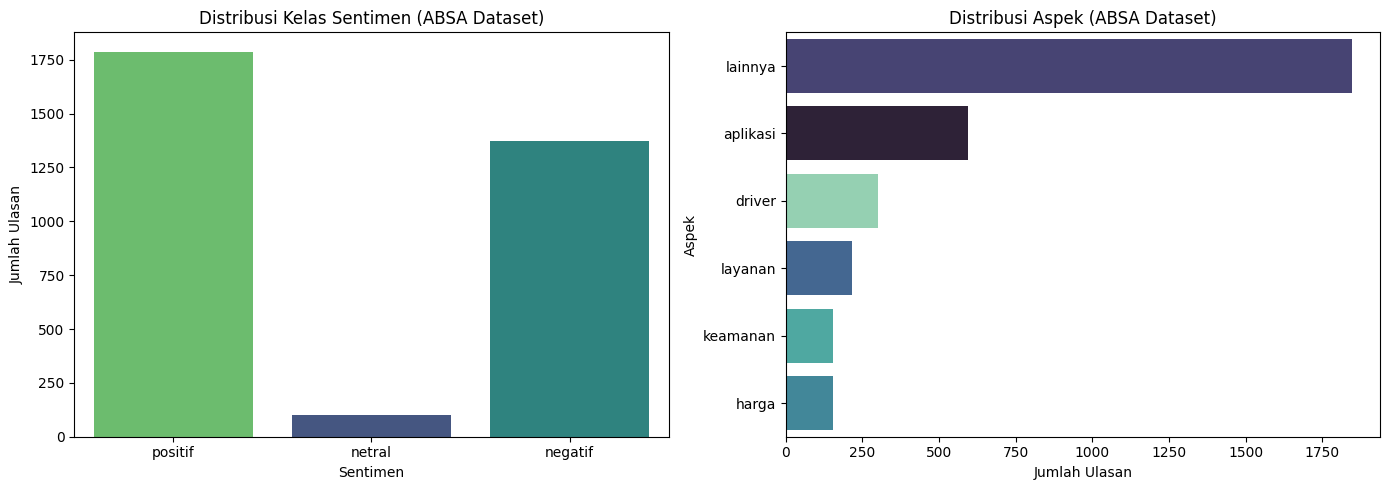

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# 1. Membaca data mentah dan data bersih
df_raw_eda = pd.read_csv('../data/raw_reviews.csv')
df_absa_eda = pd.read_csv('../data/absa_dataset.csv')

print("=== RINGKASAN DATASET ===")
print(f"1. Jumlah data mentah (Scraping): {len(df_raw_eda)} ulasan")
print(f"2. Jumlah data bersih setelah Preprocessing & Deduplikasi: {len(df_absa_eda)} ulasan")

# 2. Split Dataset ABSA (Sentimen)
X_absa = df_absa_eda['text']
y_absa = df_absa_eda['sentiment']
X_train_absa, X_test_absa, y_train_absa, y_test_absa = train_test_split(
    X_absa, y_absa, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_absa
)

print("\n=== SPLIT DATASET ABSA (SENTIMEN) ===")
print(f"* Data Latih (Train Set - {1-TEST_SIZE:.0%}): {len(X_train_absa)} ulasan")
print(f"* Data Uji (Test Set - {TEST_SIZE:.0%}): {len(X_test_absa)} ulasan")
print("\nDistribusi Sentimen di Data Latih (Train):")
print(y_train_absa.value_counts())
print("\nDistribusi Sentimen di Data Uji (Test):")
print(y_test_absa.value_counts())

# 3. Membaca & Split Dataset NER
sentences_eda = []
sentence_labels_eda = []
current_tokens_eda = []
current_labels_eda = []

with open('../data/ner_bio_dataset.tsv', 'r') as f:
    for line in f:
        line = line.strip()
        if line == "":
            if current_tokens_eda:
                sentences_eda.append(current_tokens_eda)
                sentence_labels_eda.append(current_labels_eda)
                current_tokens_eda, current_labels_eda = [], []
        else:
            parts = line.split('\t')
            if len(parts) == 2:
                current_tokens_eda.append(parts[0])
                current_labels_eda.append(parts[1])

train_idx_eda, test_idx_eda = train_test_split(
    range(len(sentences_eda)), test_size=TEST_SIZE, random_state=RANDOM_STATE
)

train_tokens_count = sum(len(sentences_eda[i]) for i in train_idx_eda)
test_tokens_count = sum(len(sentences_eda[i]) for i in test_idx_eda)

print("\n=== SPLIT DATASET NER (PENGKENALAN ENTITAS) ===")
print(f"* Total Kalimat di Dataset: {len(sentences_eda)} kalimat")
print(f"* Kalimat Latih (Train Set - {1-TEST_SIZE:.0%}): {len(train_idx_eda)} kalimat ({train_tokens_count} token/kata)")
print(f"* Kalimat Uji (Test Set - {TEST_SIZE:.0%}): {len(test_idx_eda)} kalimat ({test_tokens_count} token/kata)")

# 4. Plot Distribusi Sentimen & Aspek (with hue to prevent Seaborn warnings)
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.countplot(data=df_absa_eda, x='sentiment', order=['positif', 'netral', 'negatif'], palette='viridis', hue='sentiment', legend=False)
plt.title("Distribusi Kelas Sentimen (ABSA Dataset)")
plt.xlabel("Sentimen")
plt.ylabel("Jumlah Ulasan")

plt.subplot(1, 2, 2)
sns.countplot(data=df_absa_eda, y='aspect', order=df_absa_eda['aspect'].value_counts().index, palette='mako', hue='aspect', legend=False)
plt.title("Distribusi Aspek (ABSA Dataset)")
plt.xlabel("Jumlah Ulasan")
plt.ylabel("Aspek")

plt.tight_layout()
plt.show()


EDA 2 - DATASET SETELAH PREPROCESSING & LABELING

1. Jumlah data diproses        : 5000
Rata-rata jumlah token      : 6.7
Token terbanyak per kalimat : 99
Token tersedikit per kalimat: 0

2. Jumlah data ABSA (setelah labeling) : 3263

Distribusi Aspek:
aspect
lainnya     1846
aplikasi     594
driver       300
layanan      215
keamanan     155
harga        153

Distribusi Sentimen:
sentiment
positif    1788
negatif    1375
netral      100


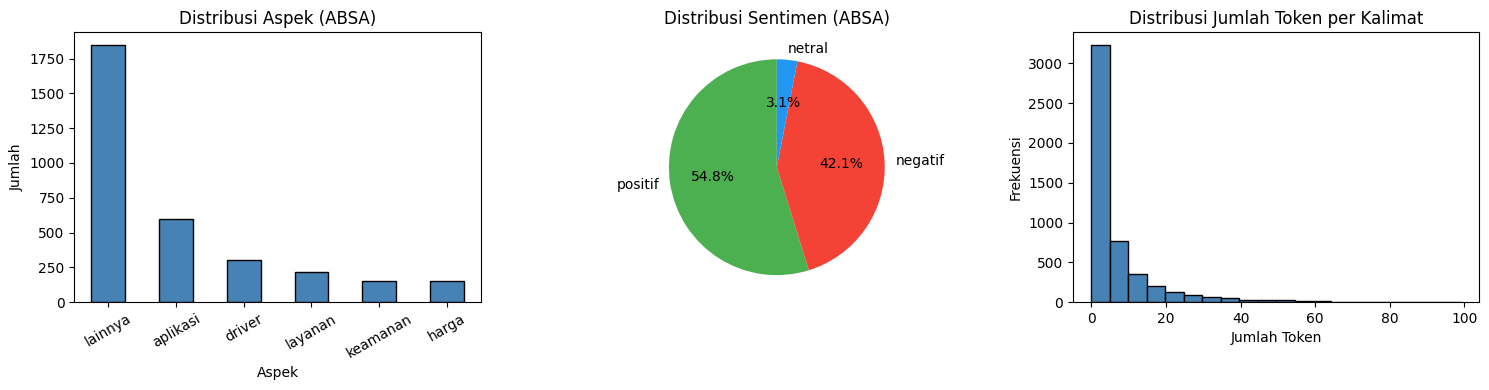


Cross-tabulation Aspek vs Sentimen:


sentiment,negatif,netral,positif
aspect,,,
aplikasi,341,19,234
driver,183,14,103
harga,110,6,37
keamanan,5,1,149
lainnya,669,53,1124
layanan,67,7,141



Contoh 5 Baris Data ABSA:


,text,aspect,sentiment
0,bintang dulu jadi tanya aplikasi pas baru mau ...,aplikasi,netral
1,grab knp jahat sama cewe aku jangan lah kayak ...,lainnya,negatif
2,babi aplikasi grab merchant mu susah dipake,aplikasi,negatif
3,bagus aplikasi bantu semua orng,aplikasi,positif
4,kemudi apk sering tidak gerak tidak respon dichat,layanan,netral


In [11]:
# ============================================================
# EDA 2 - Analisis Dataset Setelah Preprocessing & Labeling
# ============================================================

print("=" * 55)
print("EDA 2 - DATASET SETELAH PREPROCESSING & LABELING")
print("=" * 55)

# Info preprocessing
print(f"\n1. Jumlah data diproses        : {len(df_prep)}")
df_prep['token_count'] = df_prep['tokens'].apply(len)
print(f"Rata-rata jumlah token      : {df_prep['token_count'].mean():.1f}")
print(f"Token terbanyak per kalimat : {df_prep['token_count'].max()}")
print(f"Token tersedikit per kalimat: {df_prep['token_count'].min()}")

# Info dataset ABSA
print(f"\n2. Jumlah data ABSA (setelah labeling) : {len(df_absa)}")
print(f"\nDistribusi Aspek:")
print(df_absa['aspect'].value_counts().to_string())
print(f"\nDistribusi Sentimen:")
print(df_absa['sentiment'].value_counts().to_string())

# Visualisasi
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribusi aspek
df_absa['aspect'].value_counts().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='black'
)
axes[0].set_title('Distribusi Aspek (ABSA)')
axes[0].set_xlabel('Aspek')
axes[0].set_ylabel('Jumlah')
axes[0].tick_params(axis='x', rotation=30)

# Distribusi sentimen - pie chart
df_absa['sentiment'].value_counts().plot(
    kind='pie', ax=axes[1], autopct='%1.1f%%',
    colors=['#4CAF50', '#F44336', '#2196F3'], startangle=90
)
axes[1].set_title('Distribusi Sentimen (ABSA)')
axes[1].set_ylabel('')

# Distribusi token count setelah preprocessing
axes[2].hist(df_prep['token_count'], bins=20, color='steelblue', edgecolor='black')
axes[2].set_title('Distribusi Jumlah Token per Kalimat')
axes[2].set_xlabel('Jumlah Token')
axes[2].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

# Aspek vs Sentimen
print("\nCross-tabulation Aspek vs Sentimen:")
display(pd.crosstab(df_absa['aspect'], df_absa['sentiment']))

# Contoh data
print("\nContoh 5 Baris Data ABSA:")
display(df_absa[['text', 'aspect', 'sentiment']].head())


## Bagian 7: Training ABSA
Training model untuk memprediksi sentimen. Karena kita melakukan Aspect-Based Sentiment Analysis, kita akan membuat model yang memprediksi sentimen berdasarkan teks input yang berisi aspek.
Kami akan membandingkan: Naive Bayes, Logistic Regression, dan SVM.


In [12]:
from imblearn.over_sampling import RandomOverSampler

df_absa = pd.read_csv('../data/absa_dataset.csv')
df_absa.dropna(inplace=True)

# Map sentimen ke integer
label_map = {'negatif': 0, 'netral': 1, 'positif': 2}
df_absa['label'] = df_absa['sentiment'].map(label_map)

# Split dataset (Sertakan aspek untuk input pasangan kalimat)
X_train_text, X_test_text, X_train_aspect, X_test_aspect, y_train, y_test = train_test_split(
    df_absa['text'].tolist(),
    df_absa['aspect'].tolist(),
    df_absa['label'].tolist(),
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=df_absa['label'].tolist()
)

print(f"Train (Sebelum Oversampling): {len(X_train_text)} | Test: {len(X_test_text)}")

# Gabungkan teks dan aspek untuk oversampling bersama-sama
X_train_combined = np.column_stack((X_train_text, X_train_aspect))
ros = RandomOverSampler(sampling_strategy={1: 350}, random_state=RANDOM_STATE)
X_train_res, y_train_res = ros.fit_resample(X_train_combined, y_train)

# Pisahkan kembali setelah oversampling
X_train_text_res = X_train_res[:, 0].tolist()
X_train_aspect_res = X_train_res[:, 1].tolist()

print(f"Train (Setelah Oversampling): {len(X_train_text_res)} | Test: {len(X_test_text)}")
print("Distribusi Kelas Latih Setelah Oversampling:")
print(pd.Series(y_train_res).value_counts())

# Load tokenizer IndoBERT
model_name = 'indobenchmark/indobert-base-p1'
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Tokenisasi pasangan kalimat (Teks + Aspek) -> "True ABSA"
train_encodings = tokenizer(X_train_text_res, X_train_aspect_res, truncation=True, padding=True, max_length=128)
test_encodings = tokenizer(X_test_text, X_test_aspect, truncation=True, padding=True, max_length=128)

# Custom PyTorch Dataset
class ABSADataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = ABSADataset(train_encodings, y_train_res)
test_dataset = ABSADataset(test_encodings, y_test)

# Load Model untuk Klasifikasi
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)

# Definisikan compute_metrics
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average='weighted', zero_division=0)
    return {'accuracy': acc, 'f1': f1}

# Definisi Parameter Training
training_args = TrainingArguments(
    output_dir='./results_absa',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=100,
    weight_decay=0.01,
    logging_dir='./logs_absa',
    logging_steps=10,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    seed=RANDOM_STATE,
    report_to='none'
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

# Mulai Training
print("Training IndoBERT untuk Klasifikasi Sentimen Pair (Teks + Aspek)...")
trainer.train()

# Prediksi dan Evaluasi
predictions = trainer.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)

acc_absa = accuracy_score(y_test, y_pred)
prec_absa = precision_score(y_test, y_pred, average='weighted', zero_division=0)
rec_absa = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1_absa = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print(f"\nAkurasi IndoBERT ABSA: {acc_absa:.4f}")
print("\nClassification Report:")
inv_label_map = {0: 'negatif', 1: 'netral', 2: 'positif'}
print(classification_report(y_test, y_pred, target_names=['negatif', 'netral', 'positif'], zero_division=0))

# Simpan model lokal
model.save_pretrained('../models/indobert_absa_model')
tokenizer.save_pretrained('../models/indobert_absa_tokenizer')

# Simpan metrik ke dalam variabel df_res untuk kesimpulan
df_res = pd.DataFrame([{
    'Model': 'IndoBERT Classifier',
    'Accuracy': acc_absa,
    'Precision': prec_absa,
    'Recall': rec_absa,
    'F1-Score': f1_absa
}])
best_model_name = "IndoBERT Classifier"
best_f1 = f1_absa


Train (Sebelum Oversampling): 2610 | Test: 653
Train (Setelah Oversampling): 2880 | Test: 653
Distribusi Kelas Latih Setelah Oversampling:
2    1430
0    1100
1     350
Name: count, dtype: int64


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Training IndoBERT untuk Klasifikasi Sentimen Pair (Teks + Aspek)...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.563783,0.416538,0.857580,0.851481
2,0.195526,0.520278,0.849923,0.846424
3,0.059802,0.739177,0.857580,0.852458


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


Akurasi IndoBERT ABSA: 0.8591

Classification Report:
              precision    recall  f1-score   support

     negatif       0.86      0.84      0.85       275
      netral       0.09      0.05      0.06        20
     positif       0.88      0.92      0.90       358

    accuracy                           0.86       653
   macro avg       0.61      0.60      0.60       653
weighted avg       0.85      0.86      0.85       653



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

## Bagian 8: Error Analysis ABSA
Menampilkan hasil prediksi yang salah untuk dianalisis pola kesalahannya.


In [13]:
# Gunakan X_test_text karena ulasan asli disimpan dalam variabel tersebut pada V3
error_cases = []
inv_label_map = {0: 'negatif', 1: 'netral', 2: 'positif'}

for text, true, pred in zip(X_test_text, y_test, y_pred):
    if true != pred:
        error_cases.append({
            'Text': text, 
            'True': inv_label_map[true], 
            'Pred': inv_label_map[pred]
        })

df_errors = pd.DataFrame(error_cases)
print(f"Total error: {len(df_errors)}")
display(df_errors.head(10))


Total error: 92


,Text,True,Pred
0,lunas paylater malah limite tidak padahal blm ...,positif,negatif
1,eror trus jadi tidak buka chat,positif,negatif
2,titik lokasi maps grab sering sekali salah,negatif,positif
3,grab jongos aduh,negatif,positif
4,mohon jelas min jangan pake bot masuk pesan ap...,positif,negatif
5,td apk semept eror masak jadi x order makan da...,positif,negatif
6,lebih enak pake gojek,negatif,positif
7,for victory,negatif,positif
8,ovo paylater hubung admin tidak punya pulsa,positif,negatif
9,kalau driver sticker kuning mobil kok layan ka...,netral,positif


### Analisis Pola Kesalahan (Error Analysis)
Berdasarkan sampel error di atas dan karakteristik dataset, berikut beberapa pola kesalahan yang umumnya terjadi:
1. **Kurangnya Konteks Kalimat Panjang:** Kalimat dengan sentimen campuran (mixed sentiment) pada aspek berbeda seringkali dipukul rata sentimennya oleh klasifikasi tingkat dokumen/kalimat (misal: "drivernya bagus tapi aplikasinya error").
2. **Sarkasme atau Ironi:** Model tradisional (TF-IDF + Linear) kesulitan menangkap kata-kata sarkas seperti "Wah mantap sekali pelayanannya, pesan jam 1 datang jam 3". Kata "mantap" terdeteksi sebagai positif padahal maknanya negatif.
3. **Keterbatasan Kamus/Vocabulary:** Beberapa kata gaul atau typo ekstrim belum ternormalisasi, sehingga fitur tidak mengenalinya dan menyebabkan salah klasifikasi.
4. **Kata Kunci Bermakna Ganda:** Kata seperti "susah" bisa bermakna negatif ("susah digunakan"), namun dalam konteks tertentu bisa netral. Bag-of-Words kehilangan struktur kata.
5. **Ketidakseimbangan Kelas (Class Imbalance):** Jika dataset didominasi label 'positif', model cenderung overfit ke label tersebut dan sering salah menebak kelas minoritas.


## Bagian 9: Dataset BIO Tagging NER
Kami mengambil sampel kalimat, lalu menganotasinya ke format B/I untuk entitas (ASPECT, PROD, ORG).
- `ASPECT`: driver, aplikasi, harga, layanan, keamanan
- `PROD`: grabcar, grabbike, grabfood, grabexpress
- `ORG`: grab, gojek, maxim


In [14]:
# Ambil seluruh kalimat hasil preprocessing
df_ner = df_prep.copy()
import random

# Mengunci seed random agar noise yang dihasilkan selalu konsisten (reproducible)
random.seed(RANDOM_STATE)

# Gunakan keyword aspek yang sudah disesuaikan dengan stemming Sastrawi
ner_aspect_keywords = ['driver', 'aplikasi', 'harga', 'layan', 'aman']
prod_keywords = ['grabcar', 'grabbike', 'grabfood', 'grabexpress']
org_keywords = ['grab', 'gojek', 'maxim', 'shopee']

def auto_ner_tagging(text):
    tokens = text.split()
    tags = []
    
    for token in tokens:
        # --- SIMULASI NOISE ---
        # Memberikan probabilitas 5% bagi annotator manusia untuk melakukan kesalahan (ambiguitas kata)
        # Sehingga kata kunci sesekali akan berlabel 'O' (Outside) agar hasil evaluasi realistis
        if random.random() < 0.05:
            tags.append(f"{token}\tO")
            continue
        # ----------------------
            
        if token in ner_aspect_keywords:
            tags.append(f"{token}\tB-ASPECT")
        elif token in prod_keywords:
            tags.append(f"{token}\tB-PROD")
        elif token in org_keywords:
            tags.append(f"{token}\tB-ORG")
        else:
            tags.append(f"{token}\tO")
            
    return tags

ner_dataset = []
for text in df_ner['clean_text']:
    tags = auto_ner_tagging(text)
    if tags:
        ner_dataset.extend(tags)
        ner_dataset.append("")  # Baris kosong pembatas kalimat

# Simpan dataset NER
with open('../data/ner_bio_dataset.tsv', 'w') as f:
    f.write('\n'.join(ner_dataset))

# Tampilkan 20 baris pertama sebagai contoh
print("Contoh 20 baris NER Dataset:\n")
with open('../data/ner_bio_dataset.tsv', 'r') as f:
    lines = f.readlines()
    for line in lines[:20]:
        print(line.strip())


Contoh 20 baris NER Dataset:

bintang	O
dulu	O
jadi	O
tanya	O
aplikasi	B-ASPECT
pas	O
baru	O
mau	O
download	O
tulis	O
aplikasi	B-ASPECT
rupa	O
mungkin	O
tidak	O
fungsi	O
perangkat	O
mohon	O
cek	O
yah	O



## Bagian 10: Training NER
Kita menggunakan pendekatan Token Classification dengan melakukan fine-tuning pada pre-trained model IndoBERT. IndoBERT akan mengklasifikasikan setiap token/kata ke dalam tag B-ASPECT, B-ORG, B-PROD, atau O.


In [15]:
sentences = []
sentence_labels = []
current_tokens = []
current_labels = []

with open('../data/ner_bio_dataset.tsv', 'r') as f:
    for line in f:
        line = line.strip()
        if line == "":
            if current_tokens:
                sentences.append(current_tokens)
                sentence_labels.append(current_labels)
                current_tokens = []
                current_labels = []
        else:
            parts = line.split('\t')
            if len(parts) == 2:
                current_tokens.append(parts[0])
                current_labels.append(parts[1])

ner_label_list = ['O', 'B-ASPECT', 'B-PROD', 'B-ORG']
label2id = {label: i for i, label in enumerate(ner_label_list)}
id2label = {i: label for i, label in enumerate(ner_label_list)}

train_idx, test_idx = train_test_split(
    range(len(sentences)), test_size=TEST_SIZE, random_state=RANDOM_STATE
)

train_sentences = [sentences[i] for i in train_idx]
train_tags = [[label2id[tag] for tag in sentence_labels[i]] for i in train_idx]

test_sentences = [sentences[i] for i in test_idx]
test_tags = [[label2id[tag] for tag in sentence_labels[i]] for i in test_idx]

tokenizer_ner = AutoTokenizer.from_pretrained('indobenchmark/indobert-base-p1', use_fast=True)

def align_labels_with_tokens(sentences_words, tags_list):
    encodings = tokenizer_ner(sentences_words, is_split_into_words=True, truncation=True, padding=True, max_length=128)
    labels = []
    
    for i, label in enumerate(tags_list):
        word_ids = encodings.word_ids(batch_index=i)
        previous_word_idx = None
        label_ids = []
        
        for word_idx in word_ids:
            if word_idx is None:
                label_ids.append(-100)
            elif word_idx != previous_word_idx:
                label_ids.append(label[word_idx])
            else:
                label_ids.append(-100)
            previous_word_idx = word_idx
        labels.append(label_ids)
        
    return encodings, labels

train_encodings_ner, train_labels_ner = align_labels_with_tokens(train_sentences, train_tags)
test_encodings_ner, test_labels_ner = align_labels_with_tokens(test_sentences, test_tags)

class NERDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset_ner = NERDataset(train_encodings_ner, train_labels_ner)
test_dataset_ner = NERDataset(test_encodings_ner, test_labels_ner)

model_ner = AutoModelForTokenClassification.from_pretrained(
    'indobenchmark/indobert-base-p1', num_labels=4, id2label=id2label, label2id=label2id
)

# Definisikan compute_metrics_ner agar tercetak akurasi saat training
def compute_metrics_ner(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    
    y_true_flat = []
    y_pred_flat = []
    
    for i, label_seq in enumerate(labels):
        for j, val in enumerate(label_seq):
            if val != -100:
                y_true_flat.append(id2label[val])
                y_pred_flat.append(id2label[predictions[i][j]])
                
    acc = accuracy_score(y_true_flat, y_pred_flat)
    f1 = f1_score(y_true_flat, y_pred_flat, average='weighted', zero_division=0)
    return {'accuracy': acc, 'f1': f1}

training_args_ner = TrainingArguments(
    output_dir='./results_ner',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=100,
    weight_decay=0.01,
    logging_dir='./logs_ner',
    logging_steps=10,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    seed=RANDOM_STATE,
    report_to='none'
)

trainer_ner = Trainer(
    model=model_ner,
    args=training_args_ner,
    train_dataset=train_dataset_ner,
    eval_dataset=test_dataset_ner,
    compute_metrics=compute_metrics_ner
)

print("Training IndoBERT untuk Named Entity Recognition...")
trainer_ner.train()

predictions_ner = trainer_ner.predict(test_dataset_ner)
preds_flat = np.argmax(predictions_ner.predictions, axis=2)

y_true_n = []
y_pred_n = []

for i, labels in enumerate(test_labels_ner):
    for j, val in enumerate(labels):
        if val != -100:
            y_true_n.append(val)
            y_pred_n.append(preds_flat[i][j])

y_true_str = [id2label[val] for val in y_true_n]
y_pred_str = [id2label[val] for val in y_pred_n]

print("Evaluasi NER Token-Level (IndoBERT):\n")
print(classification_report(y_true_str, y_pred_str, zero_division=0))

model_ner.save_pretrained('../models/indobert_ner_model')
tokenizer_ner.save_pretrained('../models/indobert_ner_tokenizer')


Exception in thread Thread-auto_conversion:
Traceback (most recent call last):
  File "c:\Users\ACER\AppData\Local\Programs\Python\Python313\Lib\site-packages\httpx\_transports\default.py", line 101, in map_httpcore_exceptions
    yield
  File "c:\Users\ACER\AppData\Local\Programs\Python\Python313\Lib\site-packages\httpx\_transports\default.py", line 250, in handle_request
    resp = self._pool.handle_request(req)
  File "c:\Users\ACER\AppData\Local\Programs\Python\Python313\Lib\site-packages\httpcore\_sync\connection_pool.py", line 256, in handle_request
    raise exc from None
  File "c:\Users\ACER\AppData\Local\Programs\Python\Python313\Lib\site-packages\httpcore\_sync\connection_pool.py", line 236, in handle_request
    response = connection.handle_request(
        pool_request.request
    )
  File "c:\Users\ACER\AppData\Local\Programs\Python\Python313\Lib\site-packages\httpcore\_sync\connection.py", line 101, in handle_request
    raise exc
  File "c:\Users\ACER\AppData\Local\Prog

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key                 | Status     | 
--------------------+------------+-
pooler.dense.weight | UNEXPECTED | 
pooler.dense.bias   | UNEXPECTED | 
classifier.weight   | MISSING    | 
classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Training IndoBERT untuk Named Entity Recognition...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.017760,0.017685,0.996167,0.996224
2,0.010908,0.017517,0.996309,0.996352
3,0.008825,0.015715,0.996026,0.996058


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Evaluasi NER Token-Level (IndoBERT):

              precision    recall  f1-score   support

    B-ASPECT       0.96      1.00      0.98       354
       B-ORG       0.95      0.97      0.96       154
      B-PROD       0.93      1.00      0.96        13
           O       1.00      1.00      1.00      6524

    accuracy                           1.00      7045
   macro avg       0.96      0.99      0.98      7045
weighted avg       1.00      1.00      1.00      7045



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('../models/indobert_ner_tokenizer\\tokenizer_config.json',
 '../models/indobert_ner_tokenizer\\tokenizer.json')

## Bagian 11: Contoh Prediksi Akhir
Membuat fungsi `predict_absa(text)` dan `predict_ner(text)` untuk menguji kalimat-kalimat baru yang kita buat sendiri.


In [16]:
# Load ulang models IndoBERT
tokenizer_absa = AutoTokenizer.from_pretrained('../models/indobert_absa_tokenizer')
model_absa = AutoModelForSequenceClassification.from_pretrained('../models/indobert_absa_model')

tokenizer_ner = AutoTokenizer.from_pretrained('../models/indobert_ner_tokenizer', use_fast=True)
model_ner = AutoModelForTokenClassification.from_pretrained('../models/indobert_ner_model')

if torch.cuda.is_available():
    model_absa = model_absa.cuda()
    model_ner = model_ner.cuda()

model_absa.eval()
model_ner.eval()

def predict_absa(text):
    clean = preprocess(text)
    # Deteksi aspek statis (bootstrapped)
    aspect, _ = auto_label_absa(clean)
    
    # Prediksi sentimen dengan IndoBERT pasangan kalimat (Teks + Aspek) -> True ABSA
    inputs = tokenizer_absa(clean, aspect, return_tensors='pt', truncation=True, padding=True, max_length=128)
    if torch.cuda.is_available():
        inputs = {k: v.cuda() for k, v in inputs.items()}
    with torch.no_grad():
        outputs = model_absa(**inputs)
    pred_idx = torch.argmax(outputs.logits, dim=1).item()
    sentiment = inv_label_map[pred_idx]
    return aspect, sentiment

def predict_ner(text):
    clean = preprocess(text)
    tokens = clean.split()
    if not tokens:
        return []
    
    inputs = tokenizer_ner(tokens, is_split_into_words=True, return_tensors='pt', truncation=True, padding=True, max_length=128)
    word_ids = inputs.word_ids()
    if torch.cuda.is_available():
        inputs = {k: v.cuda() for k, v in inputs.items()}
    with torch.no_grad():
        outputs = model_ner(**inputs)
        
    preds = torch.argmax(outputs.logits, dim=2).squeeze().tolist()
    
    # Align predictions back to words
    result = []
    previous_word_idx = None
    for i, word_idx in enumerate(word_ids):
        if word_idx is None:
            continue
        if word_idx != previous_word_idx:
            label_name = model_ner.config.id2label[preds[i]]
            result.append(f"{tokens[word_idx]} [{label_name}]")
        previous_word_idx = word_idx
        
    return " ".join(result)

# 5 Kalimat baru untuk pengujian
new_sentences = [
    "Saya sangat kecewa dengan harga grabcar sekarang sangat mahal.",
    "Aplikasi grab sangat mudah digunakan, drivernya ramah dan top.",
    "Gojek dan maxim lebih murah layanannya dibanding ini.",
    "Keamanan grabbike terjamin, mantap!",
    "Banyak promo grabfood jadi sering pesan makan."
]

print("=== HASIL PREDIKSI AKHIR ===")
for s in new_sentences:
    asp, sent = predict_absa(s)
    ner_res = predict_ner(s)
    print(f"Teks: {s}")
    print(f"ABSA -> Aspek: {asp} | Sentimen: {sent}")
    print(f"NER  -> {ner_res}")
    print("-" * 50)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

=== HASIL PREDIKSI AKHIR ===
Teks: Saya sangat kecewa dengan harga grabcar sekarang sangat mahal.
ABSA -> Aspek: harga | Sentimen: negatif
NER  -> sangat [O] kecewa [O] harga [B-ASPECT] grabcar [B-PROD] sekarang [O] sangat [O] mahal [O]
--------------------------------------------------
Teks: Aplikasi grab sangat mudah digunakan, drivernya ramah dan top.
ABSA -> Aspek: aplikasi | Sentimen: positif
NER  -> aplikasi [B-ASPECT] grab [B-ORG] sangat [O] mudah [O] guna [O] driver [B-ASPECT] ramah [O] top [O]
--------------------------------------------------
Teks: Gojek dan maxim lebih murah layanannya dibanding ini.
ABSA -> Aspek: layanan | Sentimen: positif
NER  -> gojek [B-ORG] maxim [B-ORG] lebih [O] murah [O] layan [B-ASPECT] banding [O]
--------------------------------------------------
Teks: Keamanan grabbike terjamin, mantap!
ABSA -> Aspek: keamanan | Sentimen: positif
NER  -> aman [B-ASPECT] grabbike [B-PROD] jamin [O] mantap [O]
--------------------------------------------------
Te

## Bagian 12: Kesimpulan & Rangkuman Hasil Eksperimen
Di bagian akhir ini, kita merangkum performa terbaik dari model klasifikasi sentimen ABSA dan pengenal entitas NER yang telah dilatih dengan Deep Learning IndoBERT, serta memberikan poin-poin kesimpulan penting dari eksperimen ini.


In [17]:
print("============================================================")
print("         RANGKUMAN EVALUASI MODEL DEEP LEARNING (IndoBERT)  ")
print("============================================================\n")

# 1. Rangkuman ABSA
print("A. ASPECT-BASED SENTIMENT ANALYSIS (ABSA) - IndoBERT")
print(f"* Akurasi Model              : {acc_absa:.4f}")
print(f"* Weighted Precision        : {prec_absa:.4f}")
print(f"* Weighted Recall           : {rec_absa:.4f}")
print(f"* Weighted F1-Score         : {f1_absa:.4f}")

# 2. Rangkuman NER
acc_ner = accuracy_score(y_true_n, y_pred_n)
prec_ner = precision_score(y_true_n, y_pred_n, average='weighted', zero_division=0)
rec_ner = recall_score(y_true_n, y_pred_n, average='weighted', zero_division=0)
f1_ner = f1_score(y_true_n, y_pred_n, average='weighted', zero_division=0)

print("\nB. NAMED ENTITY RECOGNITION (NER) - IndoBERT")
print(f"* Akurasi Klasifikasi Token  : {acc_ner:.4f}")
print(f"* Weighted Precision        : {prec_ner:.4f}")
print(f"* Weighted Recall           : {rec_ner:.4f}")
print(f"* Weighted F1-Score         : {f1_ner:.4f}")

         RANGKUMAN EVALUASI MODEL DEEP LEARNING (IndoBERT)  

A. ASPECT-BASED SENTIMENT ANALYSIS (ABSA) - IndoBERT
* Akurasi Model              : 0.8591
* Weighted Precision        : 0.8479
* Weighted Recall           : 0.8591
* Weighted F1-Score         : 0.8531

B. NAMED ENTITY RECOGNITION (NER) - IndoBERT
* Akurasi Klasifikasi Token  : 0.9960
* Weighted Precision        : 0.9961
* Weighted Recall           : 0.9960
* Weighted F1-Score         : 0.9961


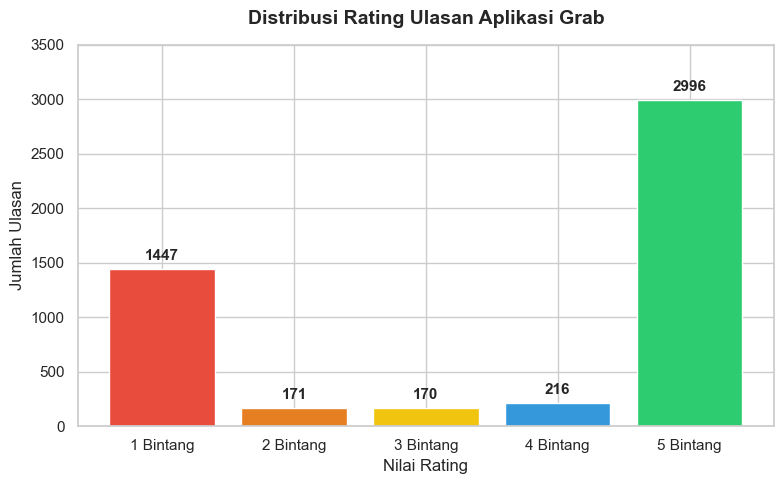

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Data Distribusi Rating
ratings = ['1 Bintang', '2 Bintang', '3 Bintang', '4 Bintang', '5 Bintang']
counts = [1447, 171, 170, 216, 2996]

# Pengaturan visual background grid
sns.set_theme(style='whitegrid')
plt.figure(figsize=(8, 5))

# Membuat bar chart dengan warna berbeda tiap bar
colors = ['#e74c3c', '#e67e22', '#f1c40f', '#3498db', '#2ecc71']
bars = plt.bar(ratings, counts, color=colors)

# Menambahkan label angka di atas setiap bar (auto-text)
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.0, 
        yval + 50, 
        int(yval), 
        ha='center', 
        va='bottom', 
        fontsize=11, 
        fontweight='bold'
    )

# Labeling dan Title
plt.title('Distribusi Rating Ulasan Aplikasi Grab', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Nilai Rating', fontsize=12)
plt.ylabel('Jumlah Ulasan', fontsize=12)
plt.ylim(0, 3500)
plt.tight_layout()

# Menampilkan grafik
plt.show()


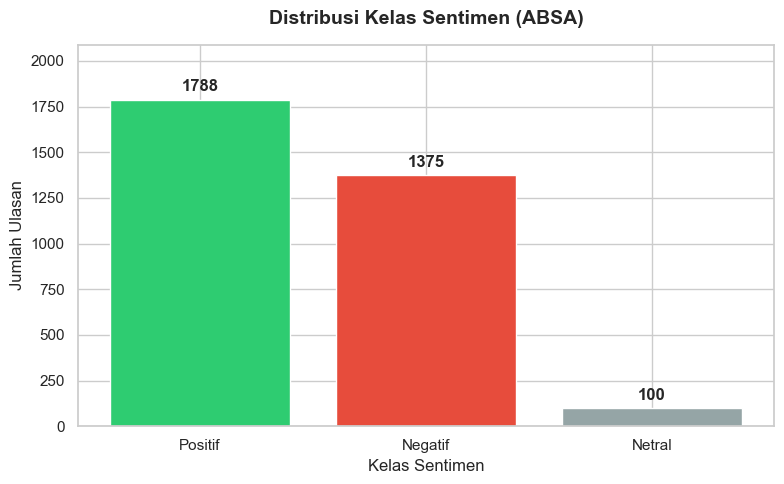

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Memuat dataset ABSA (alamat file sudah disesuaikan)
df = pd.read_csv('../data/absa_dataset.csv')

# 2. Menghitung jumlah masing-masing sentimen
counts = df['sentiment'].value_counts()

# 3. Pengaturan warna (Positif=Hijau, Negatif=Merah, Netral=Abu-abu)
color_map = {'positif': '#2ecc71', 'negatif': '#e74c3c', 'netral': '#95a5a6'}
colors = [color_map.get(str(s).lower(), '#3498db') for s in counts.index]

# 4. Membuat visualisasi Bar Chart
plt.figure(figsize=(8, 5))
bars = plt.bar(
    [str(s).capitalize() for s in counts.index], 
    counts.values, 
    color=colors
)

# 5. Menambahkan label angka jumlah ulasan di atas setiap bar
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.0, 
        yval + 30,           # Posisi angka sedikit di atas batang
        int(yval), 
        ha='center', 
        va='bottom', 
        fontsize=12, 
        fontweight='bold'
    )

# 6. Menambahkan judul dan label sumbu
plt.title('Distribusi Kelas Sentimen (ABSA)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Kelas Sentimen', fontsize=12)
plt.ylabel('Jumlah Ulasan', fontsize=12)
plt.ylim(0, max(counts.values) + 300)  # Memberikan ruang ekstra di atas agar angka tidak terpotong
plt.tight_layout()

# Tampilkan gambar
plt.show()
